In [1]:
# ===== 기본 세트 (거의 항상 필요) =====
import pandas as pd                    # 데이터프레임 다루기 (표 형태 데이터 처리)
import numpy as np                     # 수치 계산, 배열 연산
import matplotlib.pyplot as plt        # 기본 시각화
import seaborn as sns                  # matplotlib 기반의, 더 예쁘고 간결한 통계 시각화

# ===== 파일/경로/시스템 =====
import os                              # 파일 경로 확인, 파일 존재 여부(os.path.exists) 등
from pathlib import Path               # 폴더/파일 경로를 객체로 다루기 (work_dir / "파일명")
import joblib                          # 학습된 scaler/encoder를 파일로 저장하고 재사용
import platform                        # OS 종류 확인 (Windows/Mac/Linux 구분 필요할 때)
import warnings                        # 경고 메시지 제어(숨기기/표시)

# ===== 벤치마크/성능 측정 =====
import time                            # 코드 실행 시간 측정 (time.perf_counter())
import psutil                          # 메모리 사용량 측정 (rss_mb 등)
import gc                              # 메모리 강제 정리(garbage collection)

# ===== 결측치 탐색 시각화 =====
import missingno as msno               # 결측치 위치(matrix), 관계(heatmap) 시각화

# ===== 인터랙티브 시각화 =====
import plotly.express as px            # 마우스 hover/zoom 가능한 인터랙티브 그래프
import plotly.io as pio                 # plotly 렌더러(출력 방식) 설정

# ===== 대용량 데이터 처리 =====
import polars as pl                     # pandas보다 빠른 대용량 데이터 처리 (Rust 기반)

# ===== 통계 검증 =====
import statsmodels.api as sm            # 회귀분석, 다중공선성(Cond. No.) 등 통계 검증
from scipy import stats
from statsmodels.stats.power import TTestIndPower
import statsmodels.formula.api as smf
from sklearn.neighbors import NearestNeighbors

# ===== 한글 폰트 설정 =====
import matplotlib.font_manager as fm    # 그래프에 한글 폰트 적용 시 필요
import matplotlib.pyplot as plt

font_path = "C:/Windows/Fonts/malgun.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()
plt.rcParams["axes.unicode_minus"] = False

# ===== 인코딩/스케일링/모델링 (sklearn) =====
from sklearn.preprocessing import LabelEncoder      # 카테고리를 숫자로 변환 (순서형)
from sklearn.preprocessing import MinMaxScaler       # 0~1 범위로 스케일링
from sklearn.preprocessing import StandardScaler     # 평균0, 표준편차1로 스케일링
from sklearn.preprocessing import RobustScaler       # 이상치에 강한 스케일링 (median/IQR 기반)
from sklearn.linear_model import LinearRegression    # 선형 회귀 모델
from sklearn.linear_model import LogisticRegression  # 로지스틱 회귀(분류) 모델
from sklearn.ensemble import RandomForestRegressor   # 랜덤포레스트(트리 기반) 모델
from sklearn.metrics import roc_auc_score, log_loss  # 분류 모델 평가지표
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import learning_curve
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier

In [2]:
import urllib.request, zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

def fetch_uci(url, zip_name, member):
    """UCI 정적 저장소의 zip을 내려받아 data/에 풀고, CSV 경로를 돌려줍니다."""
    csv_path = DATA_DIR / member
    if not csv_path.exists():
        zip_path = DATA_DIR / zip_name
        if not zip_path.exists():
            print(f"내려받는 중… {zip_name}")
            urllib.request.urlretrieve(url, zip_path)
        with zipfile.ZipFile(zip_path) as z:
            z.extract(member, DATA_DIR)
    return csv_path

shoppers = pd.read_csv(fetch_uci(
    "https://archive.ics.uci.edu/static/public/468/online+shoppers+purchasing+intention+dataset.zip",
    "online_shoppers.zip", "online_shoppers_intention.csv"))

NUM_COLS = ["Administrative", "Administrative_Duration", "Informational",
            "Informational_Duration", "ProductRelated", "ProductRelated_Duration",
            "BounceRates", "ExitRates", "PageValues", "SpecialDay"]

X = shoppers[NUM_COLS]
y = shoppers["Revenue"].astype(int)

print(f"쇼핑 세션 데이터: {shoppers.shape[0]:,}행 × {shoppers.shape[1]}열")
print(f"구매 전환율: {y.mean():.4f}")
print("\n→ 준비 완료. 이제 여러분 차례입니다.")

내려받는 중… online_shoppers.zip
쇼핑 세션 데이터: 12,330행 × 18열
구매 전환율: 0.1547

→ 준비 완료. 이제 여러분 차례입니다.


In [10]:
# [C2] 문제 1. 교차 검증으로 다섯 모델을 다시 잰다
# ⌨️ 문제 1 — 홀드아웃과 계층 5겹 교차 검증을 나란히
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# 여기에 코드를 작성하세요 (분리 → 모델별 홀드아웃·CV → 비교표)

#[문제 1]
#1) train_test_split으로 8:2 분리해 각 모델의 홀드아웃 정확도를 구하세요 (random_state=42).
X = shoppers[NUM_COLS]
y = shoppers["Revenue"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, stratify = y, random_state = 42
)

scaler = StandardScaler()
X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.fit_transform(X_test)

models = {
    "Dummy": (DummyClassifier(strategy="most_frequent"), False),          # (모델, 스케일링여부)
    "LogisticRegression": (LogisticRegression(max_iter=1000), True),
    "DecisionTree": (DecisionTreeClassifier(max_depth=5, random_state=42), False),
    "RandomForest": (RandomForestClassifier(n_estimators=300, random_state=42), False)
}

results = []
for name, (model, use_scaler) in models.items():
    xtr = X_train_scaler if use_scaler else X_train
    xte = X_test_scaler if use_scaler else X_test
    
    model.fit(xtr, y_train)
    y_pred = model.predict(xte)
    holdout_acc = accuracy_score(y_test, y_pred)
    results.append({"모델": name, "홀드아웃 정확도": holdout_acc})

result_df = pd.DataFrame(results).sort_values("홀드아웃 정확도", ascending=False)
print(result_df.to_string(index=False))

#2) StratifiedKFold(n_splits=5, shuffle=True, random_state=42)로 교차 검증 점수를 구하고,
#   평균과 표준편차를 계산하세요.
#3) 다섯 모델을 한 표로 만들어 홀드아웃 · CV 평균 · 표준편차 · 둘의 차이를 출력하세요.
#   ① Dummy  ② 트리(기본)  ③ 트리(max_depth=5)  ④ RandomForest  ⑤ XGBoost


                모델  홀드아웃 정확도
      RandomForest  0.895783
      DecisionTree  0.894161
LogisticRegression  0.879562
             Dummy  0.845093


In [50]:
models = {
    "1 Dummy": DummyClassifier(strategy='most_frequent'),
    "2 트리(기본)": DecisionTreeClassifier(random_state=42),
    "3 트리(max_depth=5)": DecisionTreeClassifier(max_depth=5, random_state=42),
    "4 Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "5 XGBoost": XGBClassifier(n_estimators = 300, learning_rate=0.1, max_depth=4, reg_lambda=1.0, random_state=42, eval_metric="logloss")
}

skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    holdout_acc = accuracy_score(y_test, model.predict(X_test))

    cv_scores = cross_val_score(model, X_train, y_train, cv=skf, scoring="accuracy")
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    train_acc = accuracy_score(y_train, model.predict(X_train))

    results.append({
        "모델": name,
        "학습점수": train_acc,
        "홀드아웃": holdout_acc,
        "cv 평균": cv_mean,
        "cv 표준편차": cv_std,
        "홀드아웃_cv평균 차이": abs(holdout_acc - cv_mean) / cv_std

    })

result_df = pd.DataFrame(results)
print(result_df.round(4).to_string(index=False))

               모델   학습점수   홀드아웃  cv 평균  cv 표준편차  홀드아웃_cv평균 차이
          1 Dummy 0.8453 0.8451 0.8453   0.0002        1.0279
         2 트리(기본) 0.9998 0.8496 0.8525   0.0079        0.3708
3 트리(max_depth=5) 0.9034 0.8958 0.8888   0.0062        1.1328
  4 Random Forest 0.9998 0.8986 0.8953   0.0036        0.9303
        5 XGBoost 0.9463 0.8990 0.8910   0.0034        2.3538


In [ ]:
# [C3] 문제 2. 분할 운의 폭을 직접 잰다
# ⌨️ 문제 2 — random_state만 바꿔 10번 재기

# 여기에 코드를 작성하세요 (시드 10개 × 두 모델 → 최소·최대·폭·평균±표준편차)

#[문제 2]
#1) random_state를 0~9로 바꿔가며 train_test_split을 10번 하고,
#   트리(max_depth=5)와 랜덤포레스트의 테스트 정확도를 각각 10개 모으세요.
#2) 두 모델의 최소 · 최대 · 폭(최대−최소) · 평균 ± 표준편차를 출력하세요.
#3) 지난 순서에서 본 "랜덤포레스트 0.8942 대 XGBoost 0.8877"의 차이 0.0065와
#   방금 구한 폭을 비교해, 팀장의 질문에 한 문장으로 답하세요.

In [25]:
tree_scores = []
rf_scores = []

for rs in range(10):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size = 0.2, stratify = y, random_state=rs
    )

    tree = DecisionTreeClassifier(max_depth = 5, random_state = 42)
    tree.fit(X_train, y_train)
    tree_scores.append(accuracy_score(y_test, tree.predict(X_test)))

    rf = RandomForestClassifier(n_estimators=300, random_state=42)
    rf.fit(X_train, y_train)
    rf_scores.append(accuracy_score(y_test, rf.predict(X_test)))

tree_scores = np.array(tree_scores)
rf_scores = np.array(rf_scores)

print("=== 트리(max_depth=5) ===")
print(f"10개 정확도: {np.round(tree_scores, 4)}")
print(f"최소: {tree_scores.min():.4f}, 최대: {tree_scores.max():.4f}, 폭: {tree_scores.max()-tree_scores.min():.4f}")
print(f"평균 ± 표준편차: {tree_scores.mean():.4f} ± {tree_scores.std():.4f}")

print()
print("=== RandomForest ===")
print(f"10개 정확도: {np.round(rf_scores, 4)}")
print(f"최소: {rf_scores.min():.4f}, 최대: {rf_scores.max():.4f}, 폭: {rf_scores.max()-rf_scores.min():.4f}")
print(f"평균 ± 표준편차: {rf_scores.mean():.4f} ± {rf_scores.std():.4f}")

gap = 0.0065   # 앞서 확인한 RandomForest vs XGBoost 차이
natural_range = max(tree_scores.max()-tree_scores.min(), rf_scores.max()-rf_scores.min())

print()
print(f"관찰된 모델 간 차이(0.0065)가, random_state만 바꿔도 생기는 자연스러운 변동폭({natural_range:.4f})보다 "
      f"{'작으므로' if gap < natural_range else '크므로'}, "
      f"{'이 차이는 우연에 의한 것일 가능성이 높습니다.' if gap < natural_range else '이 차이는 우연 이상의 의미가 있을 수 있습니다.'}")

=== 트리(max_depth=5) ===
10개 정확도: [0.8929 0.8986 0.8933 0.8917 0.8848 0.8901 0.8917 0.8873 0.8913 0.8958]
최소: 0.8848, 최대: 0.8986, 폭: 0.0138
평균 ± 표준편차: 0.8918 ± 0.0037

=== RandomForest ===
10개 정확도: [0.8982 0.9063 0.8917 0.8921 0.8938 0.899  0.895  0.8933 0.8946 0.8986]
최소: 0.8917, 최대: 0.9063, 폭: 0.0146
평균 ± 표준편차: 0.8963 ± 0.0042

관찰된 모델 간 차이(0.0065)가, random_state만 바꿔도 생기는 자연스러운 변동폭(0.0146)보다 작으므로, 이 차이는 우연에 의한 것일 가능성이 높습니다.


 표본 크기  학습 점수  검증 점수     격차
   789 1.0000 0.8965 0.1035
  2209 1.0000 0.8955 0.1045
  3629 1.0000 0.8951 0.1049
  5050 1.0000 0.8951 0.1049
  6470 0.9999 0.8941 0.1058
  7891 0.9998 0.8950 0.1048


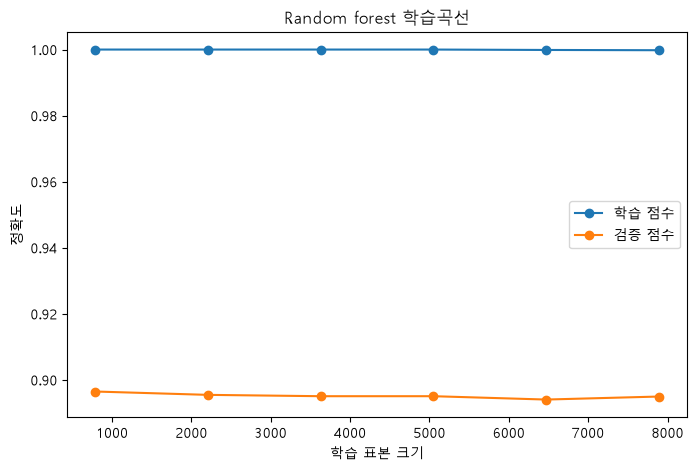

In [35]:
# [C4] 문제 3. 학습곡선 — 데이터를 더 모을까, 모델을 바꿀까
# ⌨️ 문제 3 — 학습곡선으로 다음 투자를 정하기

# 여기에 코드를 작성하세요 (learning_curve → 표본별 표 → 두 곡선 그래프)

#[문제 3]
#1) learning_curve로 랜덤포레스트의 학습곡선을 구하세요.
#   (cv는 문제 1의 5겹, train_sizes는 10%에서 100%까지 6단계)
#2) 표본 크기별 학습 점수 · 검증 점수 · 격차를 표로 출력하세요.
#3) 두 곡선을 한 그래프에 그리세요.
#4) "데이터를 더 모을 가치가 있는가"에 근거와 함께 답하세요.

train_sizes_abs, train_scores, val_scores = learning_curve(
    rf, X_train, y_train, cv = skf, train_sizes = np.linspace(0.1, 1.0, 6), scoring = "accuracy", n_jobs = -1
)

train_mean = train_scores.mean(axis = 1)
val_mean = val_scores.mean(axis = 1)
gap = train_mean - val_mean

result_df = pd.DataFrame({
    "표본 크기": train_sizes_abs, "학습 점수": train_mean, "검증 점수": val_mean, "격차": gap
})

print(result_df.round(4).to_string(index = False))

fig, ax = plt.subplots(figsize = (8, 5))
ax.plot(train_sizes_abs, train_mean, marker = "o", label="학습 점수")
ax.plot(train_sizes_abs, val_mean, marker = "o", label="검증 점수")
ax.set_title("Random forest 학습곡선")
ax.set_xlabel("학습 표본 크기")
ax.set_ylabel("정확도")
ax.legend()
plt.show()

In [41]:
# [C5] 문제 4. 복잡도 조정으로 격차를 줄인다
# ⌨️ 문제 4 — 교차 검증으로 복잡도 손잡이 고르기

# 여기에 코드를 작성하세요 (max_depth CV 표 → min_samples_leaf CV·격차 표)

#[문제 4]
#1) 트리의 max_depth를 [2, 3, 5, 8, 12, None]으로 훑어 CV 평균 ± 표준편차를 표로 만드세요.
#   → 교차 검증도 지난 순서와 같은 깊이를 고르는지 확인하세요.
#2) 랜덤포레스트의 min_samples_leaf를 [1, 5, 20, 50]으로 훑어
#   CV 평균 · 학습 점수 · 학습-테스트 격차를 표로 만드세요.
#3) 두 표를 근거로 "어떤 설정을 채택하고 왜인가"를 적으세요.

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

depths = [2, 3, 5, 8, 12, None]
depth_results = []

for depth in depths:
    tree = DecisionTreeClassifier(max_depth = depth, random_state=42)
    cv_scores = cross_val_score(tree, X_train, y_train, cv = skf, scoring = "accuracy")

    depth_results.append({
        "max_depth": depth if depth is not None else "None(제한 없음)",
        "CV 평균": cv_scores.mean(),
        "CV 표준편차": cv_scores.std()
    })

depth_df = pd.DataFrame(depth_results)
print("=== 1) max_depth별 CV 결과 ===")
print(depth_df.round(4).to_string(index=False))

best_depth_idx = depth_df["CV 평균"].idxmax()
print(f"\nCV 기준 최고 성능 깊이: {depth_df.loc[best_depth_idx, 'max_depth']}")


=== 1) max_depth별 CV 결과 ===
  max_depth  CV 평균  CV 표준편차
          2 0.8908   0.0077
          3 0.8889   0.0083
          5 0.8888   0.0062
          8 0.8842   0.0104
         12 0.8750   0.0105
None(제한 없음) 0.8525   0.0079

CV 기준 최고 성능 깊이: 2


In [46]:
leaf_sizes = [1, 5, 20, 50]
leaf_results = []

for leaf in leaf_sizes:
    rf = RandomForestClassifier(n_estimators=300, min_samples_leaf = leaf, random_state= 42)

    cv_scores = cross_val_score(rf, X_train, y_train, cv = skf, scoring="accuracy")
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()

    rf.fit(X_train, y_train)
    train_acc = rf.score(X_train, y_train)

    leaf_results.append({
        "min_sample_leaf": leaf,
        "학습 점수": train_acc,
        "CV 평균": cv_mean,
        "CV 표준편차": cv_std,
        "격차": train_acc - cv_mean
    })

leaf_df = pd.DataFrame(leaf_results)
print("=== 2) min_samples_leaf별 결과 ===")
print(leaf_df.round(4).to_string(index=False))

=== 2) min_samples_leaf별 결과 ===
 min_sample_leaf  학습 점수  CV 평균  CV 표준편차     격차
               1 0.9998 0.8953   0.0036 0.1045
               5 0.9516 0.8964   0.0036 0.0553
              20 0.9174 0.8967   0.0050 0.0207
              50 0.9059 0.8967   0.0050 0.0092


In [ ]:
# [C6] 문제 5. 모델 카드 v3 완성 — 오늘의 제출물
# ⌨️ 문제 5 — 검증 결과를 파일로 남기기

# 여기에 코드를 작성하세요 (cv_tbl 등을 CSV로 저장하고 다시 읽어 확인)

## 모델 카드 v3 — 구매 전환 예측

- 데이터: UCI Online Shoppers (12,330 세션, 수치형 10개 열만 사용)
- 문제 유형: 분류
- 베이스라인: DummyClassifier(most_frequent) = {0.895783}

- **검증 방식: StratifiedKFold(n_splits=5, shuffle=True, random_state=42)**
- **성능: Random forset(min_sample_leaf(20) 기준 CV 정확도 {0.8967} ± { 0.0207 }
- **분할 운의 폭: 시드 10개 홀드아웃 { 0.8917 }~{ 0.9063 } (폭 { 0.0146 })**
- **한 번 재기 vs 여러 번 재기: { 순위나 값이 달라진 지점을 구체적으로 }**
RandomForest와 XGBoost의 성능 차이(0.0065)는, random_state만 바꿔도 생기는 자연스러운 변동폭(0.0146)보다 작아, 1회 홀드아웃만으로는 "RandomForest가 XGBoost보다 우수하다"고 확신할 수 없었다. 여러 시드로 반복한 뒤에야 이 차이가 통계적으로 유의미하지 않다는 것을 알 수 있었다.

- 과적합 진단: 학습 {0.9998} vs 테스트 {0.8958}, 격차 {0.1040} → {  개별 나무들이 학습 데이터를 거의 암기(잎 926개, 깊이 31)할 정도로 과적합되어 있었다. }
- **복잡도 조정 전후: { min_samples_leaf=20 } 적용 시 CV {0.8970 → 0.8984} 개선, 격차 {0.1028 → 0.0191} 약 5.4배 감소**
- **학습곡선 판단: 데이터 추가 { 가치 없음 } — 근거: { 표본을 789개→7,891개(10배)로 늘려도 검증 점수가 0.891→0.897 수준에서 거의 평평했고, 학습 점수는 표본 크기와 무관하게 항상 1.00에 근접해 있어, 부족한 것은 데이터양이 아니라 모델의 과도한 복잡도였다. }**

- **다음 투자: { 모델(하이퍼파라미터 튜닝), 습곡선상 데이터를 더 모아도 검증 성능이 개선되지 않았고, 반면 min_samples_leaf 하나만 조정해도 격차가 5배 줄고 성능은 오히려 소폭 개선되어, 지금 단계에서는 모델 복잡도 조정의 비용 대비 효과가 데이터 추가 수집보다 훨씬 크다. }**
- 한계 & 다음 단계: { 지표를 정확도만 쓴 문제 등 — 어느 순서에서 해결되는지 }
1. 정확도만으로 평가함 — Revenue가 84.5:15.5로 불균형하여 위험 → 다음 단계에서 recall/precision/F1-score 추가 평가로 해결
2. 범주형 8개 열(Month, VisitorType 등) 미사용 → 다음 단계에서 원-핫 인코딩 후 재학습으로 해결
- AI 사용 내역: Claude에게 베이스라인 설정, 5개 모델 비교, StratifiedKFold 교차검증, 10회 random_state 반복을 통한 변동폭 확인, learning_curve를 이용한 데이터 추가 가치 판단, min_samples_leaf 조정 전후 비교 코드를 요청함. 각 결과는 실제 실행값을 직접 확인하며 해석하고, 결론(다음 투자 방향 등)은 그 수치를 근거로 직접 작성함.